In [1]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_csv("Fraud_Detection.csv")
df.head(35)

,step,type,amountTransferred,senderId,oldSenderBalance,newSenderBalance,ReceiverId,RecieverOldBalance,RecieverNewBalance,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0


In [3]:
df.shape

(1048575, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   step                1048575 non-null  int64  
 1   type                1048575 non-null  object 
 2   amountTransferred   1048575 non-null  float64
 3   senderId            1048575 non-null  object 
 4   oldSenderBalance    1048575 non-null  float64
 5   newSenderBalance    1048575 non-null  float64
 6   ReceiverId          1048575 non-null  object 
 7   RecieverOldBalance  1048575 non-null  float64
 8   RecieverNewBalance  1048575 non-null  float64
 9   isFraud             1048575 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 80.0+ MB


In [5]:
df.isnull().sum()

step                  0
type                  0
amountTransferred     0
senderId              0
oldSenderBalance      0
newSenderBalance      0
ReceiverId            0
RecieverOldBalance    0
RecieverNewBalance    0
isFraud               0
dtype: int64

In [6]:
df['isFraud'].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

# Understanding Frauds Through EDA

## Most Fraud occurs in Transaction Type

In [7]:
pd.crosstab(df['type'],df['isFraud'])

isFraud,0,1
type,,
CASH_IN,227130,0
CASH_OUT,373063,578
DEBIT,7178,0
PAYMENT,353873,0
TRANSFER,86189,564


KEY FINDING 1: Fraud occurs only in TRANSFER and CASH_OUT transactions.

## Fraud Vs Normal Transactions

In [8]:
df['isFraud'].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

Finding 2: Fraud is extremely rare but financially costly

## Fraudusters Transactions

In [9]:
summary = df.groupby('isFraud')['amountTransferred'].agg(
    Count='count',
    Average='mean',
    Median='median',
    Maximum='max'
).round(0)

summary

,Count,Average,Median,Maximum
isFraud,,,,
0,1047433,157540.0,76215.0,6419835.0
1,1142,1192629.0,353179.0,10000000.0


Finding 3 :Fraduster transfer larger number

In [10]:
df['AccountEmptied'] = (
    df['newSenderBalance']==0
)
pd.crosstab(df['AccountEmptied'], df['isFraud'])

isFraud,0,1
AccountEmptied,,
False,468291,9
True,579142,1133


Finding 4: Fraudsters frequently drain available balances.

## Larger Amount Transaction

In [11]:
df.groupby('isFraud')['amountTransferred'].mean()
avg_amount = df.groupby('isFraud')['amountTransferred'].mean().round(0)
print(avg_amount)

isFraud
0     157540.0
1    1192629.0
Name: amountTransferred, dtype: float64


Key Finding 5: Fraudulent transactions involve larger amounts than normal transactions

## Fraud Percentage by Transaction Type

In [12]:
fraud_rate = pd.crosstab(df['type'], df['isFraud'])

fraud_rate['FraudRate'] = (
    fraud_rate[1] /
    (fraud_rate[0] + fraud_rate[1])
) * 100

fraud_rate[['FraudRate']]

isFraud,FraudRate
type,
CASH_IN,0.000000
CASH_OUT,0.154694
DEBIT,0.000000
PAYMENT,0.000000
TRANSFER,0.650122


TRANSFER transaction type is riskiest

## Top 10 Largest Fraud Transactions

In [13]:
stats = df[df['isFraud']==1]['amountTransferred'].describe()

stats_df = pd.DataFrame(stats)
stats_df['amountTransferred'] = stats_df['amountTransferred'].map('{:,.0f}'.format)

stats_df

,amountTransferred
count,"1,142"
mean,"1,192,629"
std,"2,030,599"
min,119
25%,"86,070"
50%,"353,179"
75%,"1,248,759"
max,"10,000,000"


In [14]:
top10_fraud = df[df['isFraud'] == 1][
    ['type','amountTransferred','oldSenderBalance','newSenderBalance']
].sort_values(
    'amountTransferred',
    ascending=False
).head(10)

top10_fraud

,type,amountTransferred,oldSenderBalance,newSenderBalance
586311,TRANSFER,10000000.0,19900000.0,9887819.06
586312,CASH_OUT,10000000.0,10000000.0,0.00
1030687,TRANSFER,10000000.0,14800000.0,4830219.15
1030662,CASH_OUT,10000000.0,10000000.0,0.00
1030661,TRANSFER,10000000.0,11000000.0,987591.59
1030709,TRANSFER,10000000.0,18900000.0,8931607.89
1030710,CASH_OUT,10000000.0,10000000.0,0.00
1030688,CASH_OUT,10000000.0,10000000.0,0.00
1030559,TRANSFER,10000000.0,18600000.0,8594065.09
1030560,CASH_OUT,10000000.0,10000000.0,0.00


## Amount Transferred by Fraudelent Transcation

<Axes: xlabel='isFraud'>

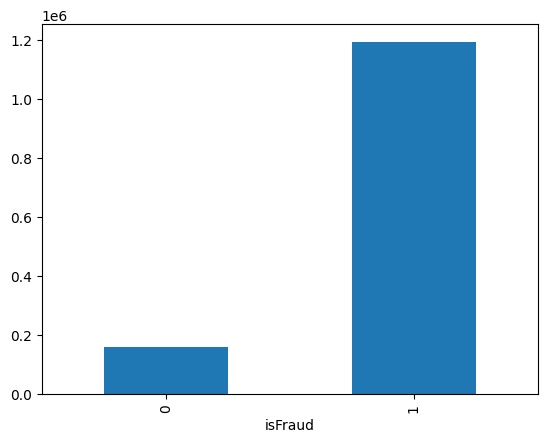

In [15]:
df.groupby('isFraud')['amountTransferred'].mean().plot(kind='bar')

# Data Preparation

## Removing IDs

In [16]:
df = df.drop(['senderId', 'ReceiverId'], axis=1)

In [17]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [18]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [23]:
print(y_train_smote.value_counts())

isFraud
0    837946
1    837946
Name: count, dtype: int64


## Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Results

In [27]:
from sklearn.metrics import accuracy_score

# Training predictions
y_train_pred = rf.predict(X_train)

# Testing predictions
y_test_pred = rf.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Training Accuracy: 1.0000 (100.00%)
Testing Accuracy:  0.9992 (99.92%)


## Confusion Matrix

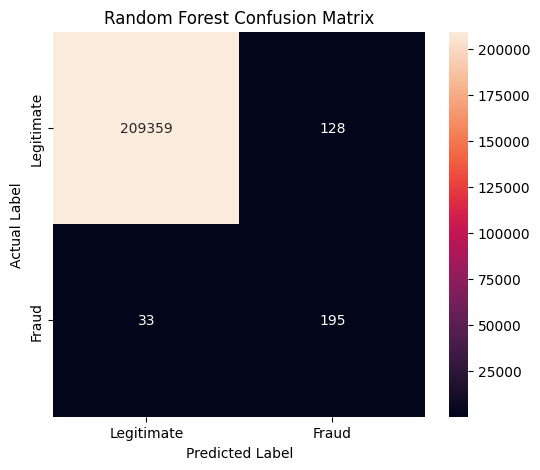

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

## Classification Report

In [35]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_test,
    y_test_pred,
    target_names=['Normal', 'Fraud']
)

print("Random Forest Classification Report:")
print(report)

Random Forest Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    209487
       Fraud       0.60      0.86      0.71       228

    accuracy                           1.00    209715
   macro avg       0.80      0.93      0.85    209715
weighted avg       1.00      1.00      1.00    209715



In [25]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from xgboost import XGBClassifier

In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [38]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [39]:
y_pred = xgb.predict(X_test)

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[209477     10]
 [    38    190]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.95      0.83      0.89       228

    accuracy                           1.00    209715
   macro avg       0.97      0.92      0.94    209715
weighted avg       1.00      1.00      1.00    209715



In [41]:
from sklearn.metrics import accuracy_score

# Training predictions
y_train_pred = xgb.predict(X_train)

# Testing predictions
y_test_pred = xgb.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Training Accuracy: 0.9999 (99.99%)
Testing Accuracy:  0.9998 (99.98%)


In [42]:
y_train_pred = xgb.predict(X_train)
print(classification_report(y_train, y_train_pred))

y_test_pred = xgb.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    837946
           1       0.95      0.93      0.94       914

    accuracy                           1.00    838860
   macro avg       0.98      0.96      0.97    838860
weighted avg       1.00      1.00      1.00    838860

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.95      0.83      0.89       228

    accuracy                           1.00    209715
   macro avg       0.97      0.92      0.94    209715
weighted avg       1.00      1.00      1.00    209715

